In [1]:
import os
os.chdir('../../../../..')

In [2]:
import polars as pl
import numpy as np

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from kmedoids import KMedoids
from hdbscan import HDBSCAN

from src.helper_functions import create_chemiscope_viewer, average_numeric_by_cluster, plot_distance_matrix_projection
from src.datasets import QM9Dataset
from src.non_euclidean import Riemann, Grassmann, Wasserstein

INFO: Enabling RDKit 2025.09.4 jupyter extensions


In [3]:
qm9 = QM9Dataset(limit=1500, descriptors=["soap"], sampling_strategy="stratified", stratify_by=["num_atoms", "gap"])
df = qm9.load()

2026-04-27 16:06:14.539 | INFO     | src.datasets:load:864 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-27 16:06:15.087 | INFO     | src.datasets:_sample_qm9_df:1064 - QM9 sampling complete: strategy=stratified, requested_limit=1651, returned_rows=1651.
2026-04-27 16:06:15.088 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=1651).
2026-04-27 16:06:15.089 | INFO     | src.features:compute_soap_outputs:374 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-04-27 16:06:16.242 | SUCCESS  | src.datasets:add_soap:1225 - Added SOAP embeddings and matrices.
2026-04-27 16:06:16.242 | INFO     | src.datasets:_add_requested_descriptors:227 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-04-27 16:06:16.248 | INFO     | src.datasets:load:903 - QM9 descriptor null-filtering complete: attempts=1, requested_limit=1500, returned_rows=1500, base_rows=1651.


# Riemann

In [4]:
riemann = Riemann()
dist_matrix_riemann = riemann.distance_matrix(df=df, descriptor='soap')

2026-04-27 16:06:16.262 | INFO     | src.non_euclidean:_load_cached_distance_matrix:286 - Loading cached riemann distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/QM9/non_euclidean_cache/riemann_n1500_soap_affine-invariant_nopca.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_36317/3592406822.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_riemann, method='complete')


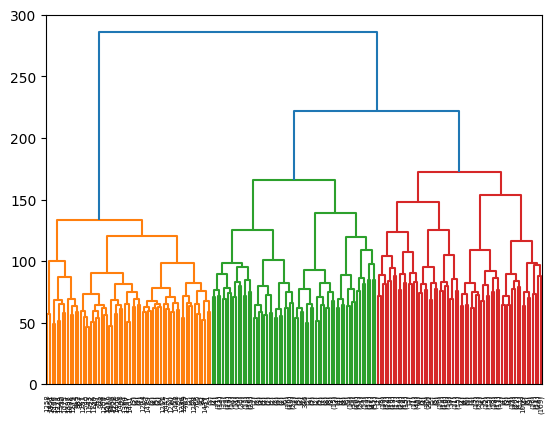

In [5]:
Z = linkage(dist_matrix_riemann, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=7, 
)

In [6]:
model_hier_riemann = AgglomerativeClustering(metric='precomputed', n_clusters=3, linkage='complete')
labels_hier_riemann = model_hier_riemann.fit_predict(dist_matrix_riemann)
print(np.unique(labels_hier_riemann, return_counts=True))
df = df.with_columns(labels_hier_riemann=labels_hier_riemann)

(array([0, 1, 2]), array([1209,  105,  186]))


In [7]:
create_chemiscope_viewer(df, dist_matrix_riemann, labels_hier_riemann, 'MDS')

2026-04-27 16:06:17.308 | INFO     | src.helper_functions:create_chemiscope_viewer:1064 - Running MDS dimensionality reduction...
2026-04-27 16:06:17.311 | INFO     | src.helper_functions:create_chemiscope_viewer:1073 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-27 16:06:46.285 | INFO     | src.helper_functions:create_chemiscope_viewer:1141 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [8]:
average_numeric_by_cluster(df, "labels_hier_riemann")

shape: (3, 71)
┌─────────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier_riemann,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1209,2.038516,0.0,121.66584,-0.006617,38.150538,0.868132,12.834725,8.717949,1.609595,0.132341,0.009926,2.477254,17.804797,2.059061,2.192721,0.08364,0.228229,0.688132,0.951199,2.07775,6.301075,0.546733,1.310174,4.383788,6.349876,36.55914,1.263077,0.001654,0.348222,0.037221,0.136476,0.129032,0.000827,0.041356,0.147229,0.529363,0.0,2.788051,73.982862,-6.543647,0.158659,6.702324,1184.437994,3.900818,-11137.385872,-11137.15693,-11137.131248,-11138.295415,31.152977,-74.368962,-74.814717,-75.238933,-69.250788,3.616011,1.403389,1.129457,74.441687,12.903226,12.655087,36.55914,511,"""Acyclic""",12.655087,179,"""C1CCCC1""",12.985939,1,null,0.0
1,105,2.146746,0.0,126.209524,0.638095,26.247619,0.912678,12.853966,8.933333,1.314286,0.028571,0.0,1.761905,21.866667,2.021475,4.047619,0.039524,0.078707,0.881769,0.695238,1.514286,7.219048,0.27619,0.561905,6.333333,6.828571,47.047619,1.249712,0.0,0.380952,0.0,0.104762,0.095238,0.0,0.009524,0.047619,0.714286,0.0,2.016745,82.617714,-6.661166,1.248432,7.909443,1376.443905,5.155706,-10975.248205,-10974.980441,-10974.954725,-10976.202223,36.435514,-88.124456,-88.691644,-89.22286,-81.830501,2.80642,1.143668,0.95156,78.095238,2.857143,19.047619,47.047619,49,"""Acyclic""",19.047619,28,"""C1CC1""",23.809524,1,null,0.0
2,186,2.187901,0.0,124.833333,0.591398,21.365591,0.932855,12.806893,8.913978,1.919355,0.0,0.0,1.467742,21.586022,2.077372,2.741935,0.016684,0.066479,0.916837,0.72043,1.231183,7.586022,0.134409,0.494624,6.817204,6.263441,47.274194,1.259767,0.0,0.473118,0.0,0.026882,0.080645,0.0,0.005376,0.032258,0.456989,0.0,1.885445,81.659516,-6.514874,1.378696,7.893584,1194.893659,5.113223,-10736.114027,-10735.867912,-10735.842206,-10737.028693,34.786086,-87.939033,-88.518618,-89.043614,-81.681562,2.715022,1.405611,1.153867,96.774194,0.0,3.225806,47.274194,117,"""C1CC1""",4.301075,61,"""C1CC1""",9.139785,1,null,0.0


In [9]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_riemann,
    fingerprint="soap",
    distance_metric="riemann",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_riemann,
    clustering_method="hierachical"
)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-27 16:07:07.498 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved MDS projection plot to figures/qm9/clustering/riemann/soap/mds_hierachical_projection.png


# Grassmann

In [10]:
grassmann = Grassmann()
dist_matrix_grass = grassmann.distance_matrix(df=df, descriptor='soap')

2026-04-27 16:07:07.518 | INFO     | src.non_euclidean:_load_cached_distance_matrix:286 - Loading cached grassmann distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/QM9/non_euclidean_cache/grassmann_n1500_soap_k3_svd_norm.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_36317/3709222914.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_grass, method='complete')


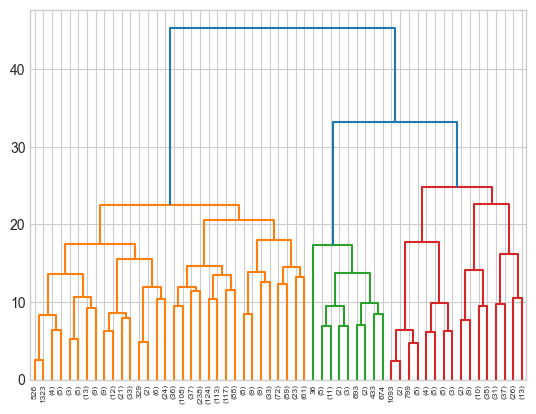

In [11]:
Z = linkage(dist_matrix_grass, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=5, 
)

In [12]:
model_hier_grass = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier_grass = model_hier_grass.fit_predict(dist_matrix_grass)
print(np.unique(labels_hier_grass, return_counts=True))
df = df.with_columns(labels_hier_grass=labels_hier_grass)

(array([0, 1, 2, 3]), array([ 265, 1165,    6,   64]))


In [13]:
create_chemiscope_viewer(df, dist_matrix_grass, labels_hier_grass, 'MDS')

2026-04-27 16:07:08.227 | INFO     | src.helper_functions:create_chemiscope_viewer:1064 - Running MDS dimensionality reduction...
2026-04-27 16:07:08.228 | INFO     | src.helper_functions:create_chemiscope_viewer:1073 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-27 16:07:36.817 | INFO     | src.helper_functions:create_chemiscope_viewer:1141 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [14]:
average_numeric_by_cluster(df, "labels_hier_grass")

shape: (4, 72)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬─────────┬────────┬────────┬────────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_hier_grass,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier_riemann,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,265,2.082281,0.0,121.433962,0.003774,35.071698,0.889325,12.828035,8.698113,1.822642,0.079245,0.026415,2.298113,18.181132,2.080104,2.049057,0.063896,0.180412,0.755692,0.928302,1.916981,6.554717,0.407547,1.041509,4.950943,5.713208,38.135849,1.266236,0.0,0.377358,0.045283,0.113208,0.120755,0.0,0.037736,0.10566,0.471698,0.0,2.751115,73.553547,-6.551208,0.3129,6.864149,1055.225118,4.020833,-11030.438206,-11030.212395,-11030.186754,-11031.330765,31.433751,-75.592718,-76.056159,-76.490088,-70.352503,3.083243,1.604916,1.311421,0.256604,86.415094,7.924528,5.660377,38.135849,161,"""Acyclic""",5.660377,79,"""C1CC1""",13.584906,1,null,0.0
1,1165,2.06828,0.0,122.745064,0.140773,35.197425,0.875706,12.834943,8.782833,1.652361,0.115021,0.004292,2.301288,18.68412,2.061179,2.426609,0.06498,0.202094,0.732926,0.898712,1.934764,6.6,0.429185,1.191416,4.860944,6.43691,38.944206,1.261856,0.001717,0.358798,0.027468,0.121888,0.11588,0.000858,0.030901,0.129614,0.549356,0.0,2.59653,75.839142,-6.538483,0.422503,6.960967,1201.008955,4.178135,-11094.426222,-11094.192527,-11094.166824,-11095.339596,32.007026,-77.486685,-77.962503,-78.409966,-72.105532,3.339927,1.371091,1.101201,0.351073,78.025751,11.158798,10.815451,38.944206,498,"""Acyclic""",10.815451,167,"""C1CCCC1""",13.218884,1,null,0.0
2,6,1.638878,0.0,114.833333,-0.166667,22.333333,0.952338,12.459278,8.666667,0.333333,0.0,0.0,1.5,14.833333,1.893308,0.666667,0.625992,0.075397,0.298611,0.5,1.0,3.166667,4.5,0.5,2.166667,8.333333,25.166667,1.249844,0.0,0.0,0.0,0.166667,0.333333,0.0,0.0,0.0,0.333333,0.0,3.430667,92.096668,-6.741621,-1.009996,5.732078,1987.830973,2.948862,-10222.058757,-10221.799642,-10221.774251,-10223.055827,31.942,-67.316763,-67.623183,-67.974399,-63.12595,12.193712,0.60257,0.56304,0.0,33.333333,0.0,66.666667,25.166667,3,"""Acyclic""",66.666667,3,"""Acyclic""",66.666667,1,null,0.0
3,64,1.964674,0.0,120.28125,0.078125,37.828125,0.895819,12.844322,8.546875,0.484375,0.125,0.0,2.40625,18.171875,1.940464,3.3125,0.18724,0.200893,0.611868,0.953125,2.0625,5.34375,1.25,1.0625,3.828125,7.75,36.03125,1.241903,0.0,0.484375,0.015625,0.125,0.1875,0.0,0.09375,0.15625,0.515625,0.0,2.478405,76.749063,-6.696977,0.16042,6.857652,1687.895161,4.027442,-11015.824448,-11015.558281,-11015.532654,-11016.814224,33.595453,-75.216328,-75.642827,-76.078961,-70.06347,6.096711,0.812286,0.722541,0.0,34.375,12.5,53.125,36.03125,12,"""Acyclic""",53.125,6,"""Acyclic""",53.125,1,null,0.0


In [15]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_grass,
    fingerprint="soap",
    distance_metric="grassmann",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_grass,
    clustering_method="hierachical"
)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-27 16:07:58.290 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved MDS projection plot to figures/qm9/clustering/grassmann/soap/mds_hierachical_projection.png


# Wasserstein

In [16]:
wasserstein = Wasserstein()
dist_matrix_wasser = wasserstein.distance_matrix(df=df, descriptor='soap')

2026-04-27 16:07:58.306 | INFO     | src.non_euclidean:_load_cached_distance_matrix:286 - Loading cached wasserstein distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/QM9/non_euclidean_cache/wasserstein_n1500_soap_sqeuclidean.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_36317/1791206022.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_wasser, method='complete')


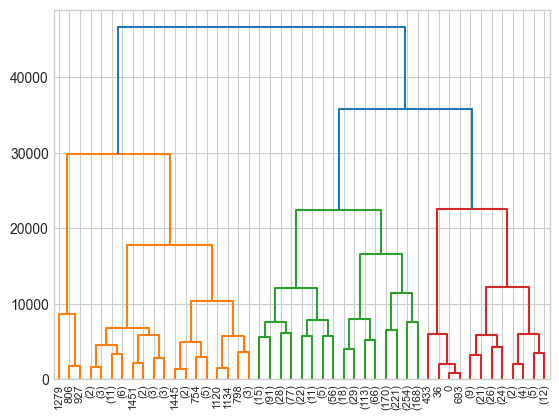

In [17]:
Z = linkage(dist_matrix_wasser, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=5, 
)

In [23]:
model_hier_wasser = AgglomerativeClustering(metric='precomputed', n_clusters=5, linkage='complete')
labels_hier_wasser = model_hier_wasser.fit_predict(dist_matrix_wasser)
print(np.unique(labels_hier_wasser, return_counts=True))
df = df.with_columns(labels_hier_wasser=labels_hier_wasser)

(array([0, 1, 2, 3, 4]), array([259, 598,  14,  98, 531]))


In [24]:
create_chemiscope_viewer(df, dist_matrix_wasser, labels_hier_wasser, 'MDS')

2026-04-27 16:11:30.379 | INFO     | src.helper_functions:create_chemiscope_viewer:1064 - Running MDS dimensionality reduction...
2026-04-27 16:11:30.380 | INFO     | src.helper_functions:create_chemiscope_viewer:1073 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-27 16:11:50.492 | INFO     | src.helper_functions:create_chemiscope_viewer:1141 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [20]:
average_numeric_by_cluster(df, "labels_hier_wasser")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬───────────┬───────────┬──────────┬────────┬────────┬────────┬───────────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_hier_wasser,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier_riemann,labels_hier_grass,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,629,1.95556,0.0,119.602544,-0.049285,43.993641,0.829174,12.847784,8.594595,1.27186,0.241653,0.009539,2.780604,16.45469,2.027326,2.195548,0.127862,0.319186,0.552951,0.977742,2.324324,5.697933,0.81876,1.717011,3.278219,6.527822,32.400636,1.260202,0.00318,0.249603,0.068362,0.208267,0.144674,0.0,0.055644,0.162162,0.484897,0.0,3.003534,72.022067,-6.575608,-0.214472,6.361178,1219.462144,3.476341,-11137.029885,-11136.801779,-11136.776116,-11137.945798,30.247512,-69.642881,-70.03625,-70.424949,-64.940583,4.177416,1.338637,1.063003,0.011129,1.071542,58.346582,23.529412,18.124006,32.400636,224,"""Acyclic""",18.124006,74,"""C1CCCC1""",19.236884,1,null,0.0
1,857,2.141659,0.0,124.373396,0.206534,29.242707,0.915163,12.821954,8.873979,1.890315,0.012835,0.007001,1.980163,20.001167,2.082208,2.519253,0.032611,0.111088,0.856301,0.861144,1.670945,7.099183,0.233372,0.75846,5.901984,6.267211,42.911319,1.263059,0.0,0.453909,0.002334,0.057176,0.103851,0.001167,0.019837,0.101517,0.575263,0.0,2.372186,77.896208,-6.522347,0.804228,7.326556,1184.027118,4.59258,-11049.659326,-11049.421898,-11049.396193,-11050.570584,33.130986,-82.055771,-82.579973,-83.062213,-76.274984,2.930254,1.418788,1.160083,0.515753,0.803967,91.248541,1.283547,7.467911,42.911319,429,"""Acyclic""",7.467911,178,"""C1CC1""",10.851809,1,null,0.0
2,14,2.248156,0.0,124.785714,1.642857,8.642857,0.933539,12.804262,8.928571,1.5,0.0,0.0,0.5,24.714286,2.029327,3.285714,0.0,0.04195,0.95805,0.285714,0.428571,8.5,0.0,0.357143,8.071429,5.857143,55.571429,1.24911,0.0,0.214286,0.0,0.071429,0.071429,0.0,0.0,0.0,0.142857,0.0,0.787079,89.277144,-6.91072,1.787205,8.697731,1214.959769,6.145528,-9976.282157,-9976.015765,-9975.990095,-9977.202079,38.639285,-99.616884,-100.302866,-100.912457,-92.420617,2.328814,1.451579,1.230451,2.0,0.428571,92.857143,0.0,7.142857,55.571429,11,"""C1CCC1""",21.428571,10,"""C1CCC1""",21.428571,1,null,0.0


In [25]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_wasser,
    fingerprint="soap",
    distance_metric="wasserstein",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_wasser,
    clustering_method="hierachical"
)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-27 16:14:24.963 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved MDS projection plot to figures/qm9/clustering/wasserstein/soap/mds_hierachical_projection.png
